# 04. Lorenz-63 Adjoint Model Check

이 노트북에서는 Lorenz-63 Euler TLM에 대응하는 adjoint model을 구현하고 검증한다.

이번 실습의 목표는 다음과 같다.

1. TLM과 adjoint model의 관계를 이해한다.
2. Euler TLM matrix의 adjoint가 transpose matrix임을 확인한다.
3. one-step inner product test를 수행한다.
4. multi-step inner product test를 수행한다.
5. adjoint variable이 시간에 대해 backward로 전파되는 구조를 확인한다.

이번 실습은 이후 4D-Var gradient 계산의 핵심 기초가 된다.

## 1. 라이브러리 불러오기

이번 실습에서는 기존에 만든 forward model, Euler 적분기, TLM, adjoint module을 사용한다.

In [1]:
import sys
from pathlib import Path

# --- bootstrap: 프로젝트 루트의 src/ 를 sys.path 에 추가해 lorenz_da import 를 보장한다 ---
#     editable 설치 위치에 의존하지 않으므로, 프로젝트를 다른 경로로 옮겨도 동작한다.
_p = Path.cwd().resolve()
for _d in (_p, *_p.parents):
    if (_d / "pyproject.toml").exists() or (_d / ".git").exists():
        if str(_d / "src") not in sys.path:
            sys.path.insert(0, str(_d / "src"))
        break

import numpy as np
import matplotlib.pyplot as plt

from lorenz_da.models.lorenz63 import (
    lorenz63_rhs,
    lorenz63_default_initial_condition,
)
from lorenz_da.numerics.euler import (
    integrate_euler,
)
from lorenz_da.tlm.lorenz63_tlm import (
    lorenz63_jacobian,
    euler_tlm_matrix,
    euler_tlm_step,
    integrate_euler_tlm,
)
from lorenz_da.adjoint.lorenz63_adjoint import (
    euler_adjoint_matrix,
    euler_adjoint_step,
    integrate_euler_adjoint,
    inner_product,
    relative_inner_product_error,
)

from lorenz_da.utils.io import find_project_root, get_output_dirs

## 2. 프로젝트 경로 설정

노트북이 `notebooks/` 안에서 실행될 수도 있고, 프로젝트 루트에서 실행될 수도 있으므로 경로를 자동으로 설정한다.

In [2]:
PROJECT_ROOT = find_project_root()
paths = get_output_dirs(PROJECT_ROOT)
FIGURE_DIR = paths["figures"]
TRAJECTORY_DIR = paths["trajectories"]
ASSIM_DIR = paths["assimilation"]
CKPT_DIR = paths["checkpoints"]

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/sanggyu/projects/lorenz-da-lab
Figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures


## 3. TLM과 adjoint의 관계

Euler nonlinear model은 다음과 같다.

$$
\mathbf{x}_{n+1}
=
\mathbf{x}_n
+
\Delta t f(\mathbf{x}_n)
$$

이에 대한 tangent linear model은 다음과 같다.

$$
\delta \mathbf{x}_{n+1}
=
M_n \delta \mathbf{x}_n
$$

여기서

$$
M_n
=
I + \Delta t J(\mathbf{x}_n)
$$

이다.

Adjoint model은 TLM matrix의 transpose를 이용해 다음과 같이 정의된다.

$$
\lambda_n
=
M_n^T \lambda_{n+1}
$$

여기서 $\lambda$는 adjoint variable이다.

TLM은 perturbation을 forward 방향으로 전파하지만, adjoint model은 adjoint variable을 backward 방향으로 전파한다.

In [3]:
dt = 0.005

state = lorenz63_default_initial_condition()

J = lorenz63_jacobian(state)
M = euler_tlm_matrix(state=state, dt=dt)
MT = euler_adjoint_matrix(state=state, dt=dt)

print("state:")
print(state)

print("\nJacobian J:")
print(J)

print("\nEuler TLM matrix M = I + dt J:")
print(M)

print("\nEuler adjoint matrix M.T:")
print(MT)

state:
[1. 1. 1.]

Jacobian J:
[[-10.          10.           0.        ]
 [ 27.          -1.          -1.        ]
 [  1.           1.          -2.66666667]]

Euler TLM matrix M = I + dt J:
[[ 0.95        0.05        0.        ]
 [ 0.135       0.995      -0.005     ]
 [ 0.005       0.005       0.98666667]]

Euler adjoint matrix M.T:
[[ 0.95        0.135       0.005     ]
 [ 0.05        0.995       0.005     ]
 [ 0.         -0.005       0.98666667]]


## 4. One-step inner product test

Adjoint model이 올바르게 구현되었는지 확인하는 가장 기본적인 방법은 inner product test이다.

TLM matrix를 $M$이라고 하면 다음 관계가 성립해야 한다.

$$
\langle M \delta \mathbf{x}, \lambda \rangle
=
\langle \delta \mathbf{x}, M^T \lambda \rangle
$$

여기서

- $\delta \mathbf{x}$: tangent linear perturbation
- $\lambda$: adjoint variable
- $M$: TLM matrix
- $M^T$: adjoint matrix

이 관계가 수치적으로 거의 같으면 adjoint 구현이 올바르다고 볼 수 있다.

In [4]:
delta = np.array([0.3, -0.4, 0.2])
lambda_next = np.array([1.2, -0.7, 0.5])

# TLM forward one-step
delta_next = euler_tlm_step(
    perturbation=delta,
    state=state,
    dt=dt,
)

# Adjoint backward one-step
lambda_current = euler_adjoint_step(
    adjoint_next=lambda_next,
    state=state,
    dt=dt,
)

lhs = inner_product(delta_next, lambda_next)
rhs = inner_product(delta, lambda_current)

rel_error = relative_inner_product_error(lhs, rhs)

print("delta:")
print(delta)

print("\nlambda_next:")
print(lambda_next)

print("\nTLM result, delta_next = M delta:")
print(delta_next)

print("\nAdjoint result, lambda_current = M.T lambda_next:")
print(lambda_current)

print("\nInner product test")
print("lhs = <M delta, lambda_next>:", lhs)
print("rhs = <delta, M.T lambda_next>:", rhs)
print("absolute error:", abs(lhs - rhs))
print("relative error:", rel_error)

delta:
[ 0.3 -0.4  0.2]

lambda_next:
[ 1.2 -0.7  0.5]

TLM result, delta_next = M delta:
[ 0.265      -0.3585      0.19683333]

Adjoint result, lambda_current = M.T lambda_next:
[ 1.048      -0.634       0.49683333]

Inner product test
lhs = <M delta, lambda_next>: 0.6673666666666667
rhs = <delta, M.T lambda_next>: 0.6673666666666667
absolute error: 0.0
relative error: 0.0


## 5. One-step inner product test 반복

임의의 perturbation과 adjoint vector를 여러 번 생성해서 inner product test를 반복한다.

올바르게 구현되었다면 모든 경우에서 상대오차가 machine precision 수준으로 작아야 한다.

In [5]:
rng = np.random.default_rng(42)

n_tests = 10
errors = []

for i in range(n_tests):
    delta = rng.normal(size=3)
    lambda_next = rng.normal(size=3)

    delta_next = euler_tlm_step(
        perturbation=delta,
        state=state,
        dt=dt,
    )

    lambda_current = euler_adjoint_step(
        adjoint_next=lambda_next,
        state=state,
        dt=dt,
    )

    lhs = inner_product(delta_next, lambda_next)
    rhs = inner_product(delta, lambda_current)

    err = relative_inner_product_error(lhs, rhs)
    errors.append(err)

    print(f"test {i + 1:02d}: relative error = {err:.6e}")

errors = np.array(errors)

print("\nmax relative error:", errors.max())
print("mean relative error:", errors.mean())

test 01: relative error = 0.000000e+00
test 02: relative error = 0.000000e+00
test 03: relative error = 0.000000e+00
test 04: relative error = 2.447429e-16
test 05: relative error = 4.158290e-16
test 06: relative error = 0.000000e+00
test 07: relative error = 0.000000e+00
test 08: relative error = 2.883081e-16
test 09: relative error = 1.110450e-15
test 10: relative error = 2.922999e-16

max relative error: 1.1104498070112839e-15
mean relative error: 2.3516296938350063e-16


## 6. 기준 trajectory 생성

이제 여러 time step에 대한 adjoint를 검증한다.

기준 trajectory는 Lorenz-63 nonlinear model을 Euler 방법으로 적분해서 만든다.

설정은 다음과 같다.

- 초기조건: `[1, 1, 1]`
- 시간간격: `dt = 0.005`
- 전체 시간: `tmax = 5`

너무 긴 시간창을 사용하면 TLM perturbation 자체가 매우 커질 수 있으므로, adjoint test에서는 먼저 짧은 시간창을 사용한다.

In [6]:
dt = 0.005
tmax = 5.0
nsteps = int(tmax / dt)

time = np.arange(nsteps + 1) * dt

x0_ref = lorenz63_default_initial_condition()

trajectory_ref = integrate_euler(
    x0=x0_ref,
    dt=dt,
    nsteps=nsteps,
    rhs_func=lorenz63_rhs,
)

print("dt:", dt)
print("tmax:", tmax)
print("nsteps:", nsteps)
print("trajectory_ref shape:", trajectory_ref.shape)

dt: 0.005
tmax: 5.0
nsteps: 1000
trajectory_ref shape: (1001, 3)


## 7. Multi-step TLM과 adjoint 관계

여러 time step을 생각하면 TLM은 다음과 같이 perturbation을 forward로 전파한다.

$$
\delta \mathbf{x}_N
=
M_{N-1} M_{N-2} \cdots M_0 \delta \mathbf{x}_0
$$

Adjoint는 반대로 terminal adjoint variable에서 시작해 backward로 전파한다.

$$
\lambda_0
=
M_0^T M_1^T \cdots M_{N-1}^T \lambda_N
$$

따라서 다음 inner product 관계가 성립해야 한다.

$$
\langle \delta \mathbf{x}_N, \lambda_N \rangle
=
\langle \delta \mathbf{x}_0, \lambda_0 \rangle
$$

In [7]:
delta0 = np.array([1.0, 0.0, 0.0])
lambda_terminal = np.array([0.5, -1.0, 0.3])

# TLM forward integration
tlm_delta = integrate_euler_tlm(
    perturbation0=delta0,
    reference_trajectory=trajectory_ref,
    dt=dt,
)

# Adjoint backward integration
adjoints = integrate_euler_adjoint(
    terminal_adjoint=lambda_terminal,
    reference_trajectory=trajectory_ref,
    dt=dt,
)

deltaN = tlm_delta[-1]
lambda0 = adjoints[0]

lhs = inner_product(deltaN, lambda_terminal)
rhs = inner_product(delta0, lambda0)

rel_error = relative_inner_product_error(lhs, rhs)

print("delta0:")
print(delta0)

print("\nlambda_terminal:")
print(lambda_terminal)

print("\ndeltaN from TLM:")
print(deltaN)

print("\nlambda0 from adjoint:")
print(lambda0)

print("\nMulti-step inner product test")
print("lhs = <delta_N, lambda_N>:", lhs)
print("rhs = <delta_0, lambda_0>:", rhs)
print("absolute error:", abs(lhs - rhs))
print("relative error:", rel_error)

delta0:
[1. 0. 0.]

lambda_terminal:
[ 0.5 -1.   0.3]

deltaN from TLM:
[-1.38216643  2.76328897  7.22735788]

lambda0 from adjoint:
[-1.28616482 -0.88008188 -4.6512275 ]

Multi-step inner product test
lhs = <delta_N, lambda_N>: -1.2861648159833083
rhs = <delta_0, lambda_0>: -1.2861648159833712
absolute error: 6.283862319378386e-14
relative error: 4.8857364478392245e-14


## 8. Multi-step inner product test 반복

이번에는 임의의 초기 perturbation과 terminal adjoint를 여러 번 생성해서 multi-step inner product test를 반복한다.

In [8]:
rng = np.random.default_rng(123)

n_tests = 10
multi_errors = []

for i in range(n_tests):
    delta0 = rng.normal(size=3)
    lambda_terminal = rng.normal(size=3)

    tlm_delta = integrate_euler_tlm(
        perturbation0=delta0,
        reference_trajectory=trajectory_ref,
        dt=dt,
    )

    adjoints = integrate_euler_adjoint(
        terminal_adjoint=lambda_terminal,
        reference_trajectory=trajectory_ref,
        dt=dt,
    )

    lhs = inner_product(tlm_delta[-1], lambda_terminal)
    rhs = inner_product(delta0, adjoints[0])

    err = relative_inner_product_error(lhs, rhs)
    multi_errors.append(err)

    print(f"test {i + 1:02d}: relative error = {err:.6e}")

multi_errors = np.array(multi_errors)

print("\nmax relative error:", multi_errors.max())
print("mean relative error:", multi_errors.mean())

test 01: relative error = 3.426806e-16
test 02: relative error = 2.179964e-16
test 03: relative error = 1.086369e-15
test 04: relative error = 1.992063e-15
test 05: relative error = 7.908021e-15
test 06: relative error = 1.070432e-15
test 07: relative error = 7.578251e-15
test 08: relative error = 3.150632e-14
test 09: relative error = 2.486315e-15
test 10: relative error = 1.424775e-15

max relative error: 3.150631872465905e-14
mean relative error: 5.56132214359466e-15


## 9. Adjoint variable 시계열 확인

Adjoint model은 terminal time에서 시작해 backward 방향으로 전파된다.

하지만 배열에는 각 물리시간에 해당하는 adjoint variable을 저장했기 때문에, 그림에서는 `time` 축에 대해 $\lambda(t)$를 그릴 수 있다.

여기서는 하나의 terminal adjoint vector를 정하고, backward propagation 결과를 확인한다.

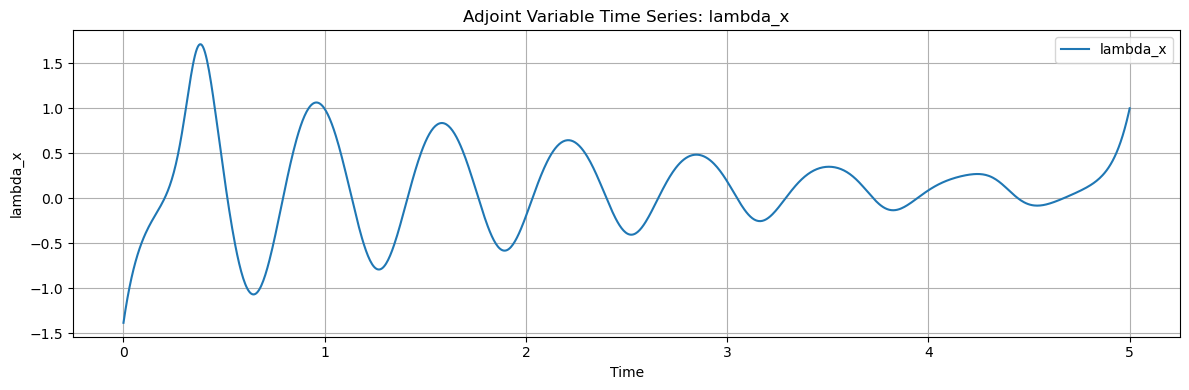

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/04_adjoint_lambda_x_timeseries.png


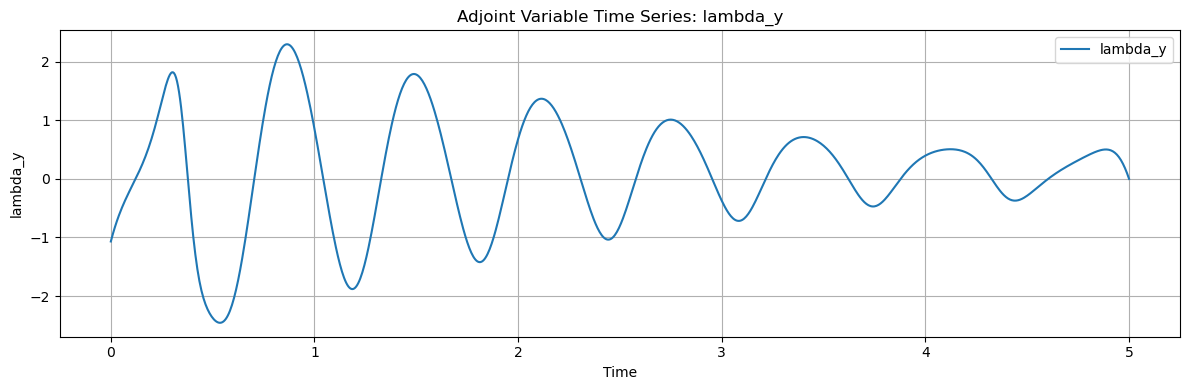

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/04_adjoint_lambda_y_timeseries.png


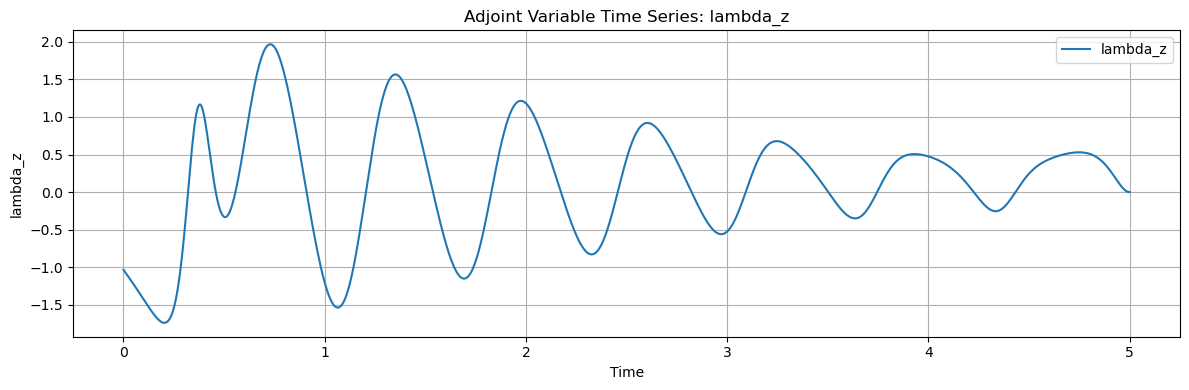

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/04_adjoint_lambda_z_timeseries.png


In [9]:
lambda_terminal = np.array([1.0, 0.0, 0.0])

adjoints = integrate_euler_adjoint(
    terminal_adjoint=lambda_terminal,
    reference_trajectory=trajectory_ref,
    dt=dt,
)

var_names = ["lambda_x", "lambda_y", "lambda_z"]

for i, name in enumerate(var_names):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(time, adjoints[:, i], label=name)

    ax.set_xlabel("Time")
    ax.set_ylabel(name)
    ax.set_title(f"Adjoint Variable Time Series: {name}")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"04_adjoint_{name}_timeseries.png"
    fig.savefig(fig_path, dpi=150)

    plt.show()

    print("Saved figure:", fig_path)

## 10. Adjoint norm 확인

Adjoint variable의 크기가 시간에 따라 어떻게 변하는지 확인한다.

다음 값을 계산한다.

$$
\|\lambda(t)\|_2
$$

Adjoint는 terminal time에서 시작해 backward 방향으로 전파되므로, 그림에서 왼쪽으로 갈수록 과거 시점의 sensitivity를 나타낸다고 볼 수 있다.

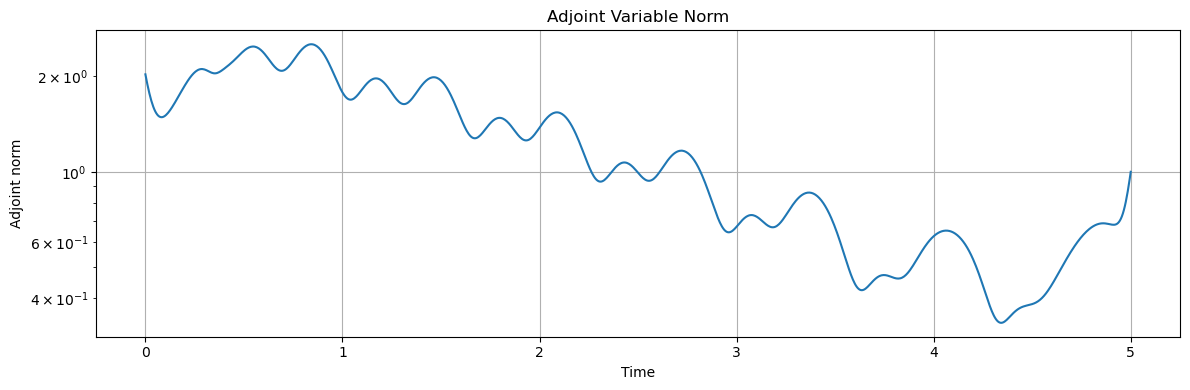

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/04_adjoint_norm.png
Initial-time adjoint norm: 2.030672202746622
Terminal-time adjoint norm: 1.0


In [10]:
adjoint_norm = np.linalg.norm(adjoints, axis=1)

fig, ax = plt.subplots(figsize=(12, 4))

ax.semilogy(time, adjoint_norm)

ax.set_xlabel("Time")
ax.set_ylabel("Adjoint norm")
ax.set_title("Adjoint Variable Norm")
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "04_adjoint_norm.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)
print("Initial-time adjoint norm:", adjoint_norm[0])
print("Terminal-time adjoint norm:", adjoint_norm[-1])

## 11. 다른 terminal adjoint 방향 비교

Terminal adjoint vector의 방향을 바꾸면 backward로 전파되는 sensitivity 구조도 달라진다.

여기서는 다음 세 가지 terminal adjoint를 비교한다.

```text
[1, 0, 0]
[0, 1, 0]
[0, 0, 1]

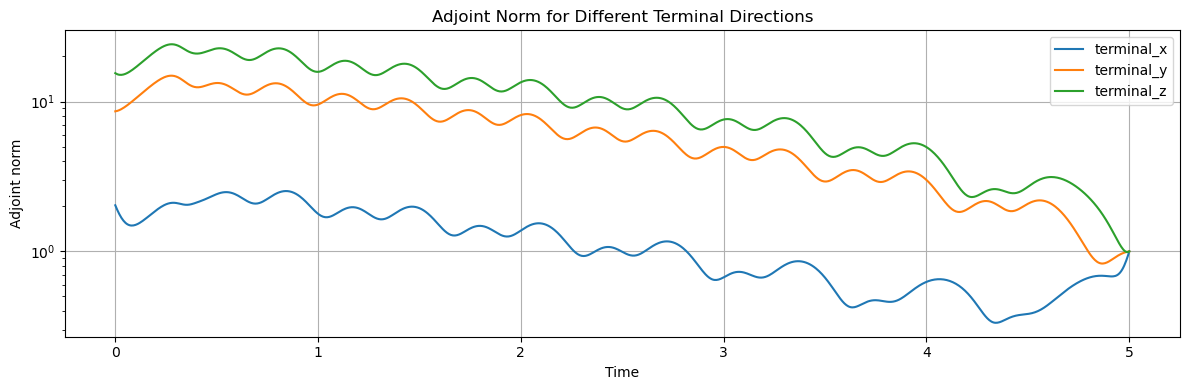

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/04_adjoint_norm_terminal_directions.png


In [11]:
terminal_vectors = {
    "terminal_x": np.array([1.0, 0.0, 0.0]),
    "terminal_y": np.array([0.0, 1.0, 0.0]),
    "terminal_z": np.array([0.0, 0.0, 1.0]),
}

adjoint_results = {}

for label, terminal_vec in terminal_vectors.items():
    adjoint_results[label] = integrate_euler_adjoint(
        terminal_adjoint=terminal_vec,
        reference_trajectory=trajectory_ref,
        dt=dt,
    )

fig, ax = plt.subplots(figsize=(12, 4))

for label, adj in adjoint_results.items():
    norm = np.linalg.norm(adj, axis=1)
    ax.semilogy(time, norm, label=label)

ax.set_xlabel("Time")
ax.set_ylabel("Adjoint norm")
ax.set_title("Adjoint Norm for Different Terminal Directions")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "04_adjoint_norm_terminal_directions.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 12. 시간창 길이에 따른 inner product test

Adjoint test는 수학적으로는 시간창 길이와 무관하게 성립해야 한다.

하지만 시간창이 길어지면 TLM과 adjoint 변수의 크기가 커질 수 있고, floating-point 오차도 누적될 수 있다.

이번에는 여러 시간창 길이에 대해 multi-step inner product test의 상대오차를 확인한다.

In [12]:
window_lengths = [0.5, 1.0, 2.0, 5.0, 10.0]

rng = np.random.default_rng(2024)

window_errors = []

for window_tmax in window_lengths:
    window_nsteps = int(window_tmax / dt)
    window_time = np.arange(window_nsteps + 1) * dt

    window_trajectory = integrate_euler(
        x0=x0_ref,
        dt=dt,
        nsteps=window_nsteps,
        rhs_func=lorenz63_rhs,
    )

    delta0 = rng.normal(size=3)
    lambda_terminal = rng.normal(size=3)

    tlm_delta = integrate_euler_tlm(
        perturbation0=delta0,
        reference_trajectory=window_trajectory,
        dt=dt,
    )

    adjoints_window = integrate_euler_adjoint(
        terminal_adjoint=lambda_terminal,
        reference_trajectory=window_trajectory,
        dt=dt,
    )

    lhs = inner_product(tlm_delta[-1], lambda_terminal)
    rhs = inner_product(delta0, adjoints_window[0])

    err = relative_inner_product_error(lhs, rhs)
    window_errors.append(err)

    print(
        f"window = {window_tmax:4.1f}, "
        f"nsteps = {window_nsteps:5d}, "
        f"relative error = {err:.6e}"
    )

window_errors = np.array(window_errors)

window =  0.5, nsteps =   100, relative error = 9.463770e-16
window =  1.0, nsteps =   200, relative error = 3.684779e-16
window =  2.0, nsteps =   400, relative error = 1.116579e-14
window =  5.0, nsteps =  1000, relative error = 1.694292e-15
window = 10.0, nsteps =  2000, relative error = 2.012192e-14


## 13. 시간창 길이에 따른 relative error 시각화

시간창 길이에 따른 inner product test error를 시각화한다.

대체로 machine precision 근처의 작은 값이 나와야 한다.

시간창이 길어질수록 round-off error가 커질 수는 있지만, 큰 오차가 난다면 adjoint 구현 또는 시간 index 처리에 문제가 있을 가능성이 있다.

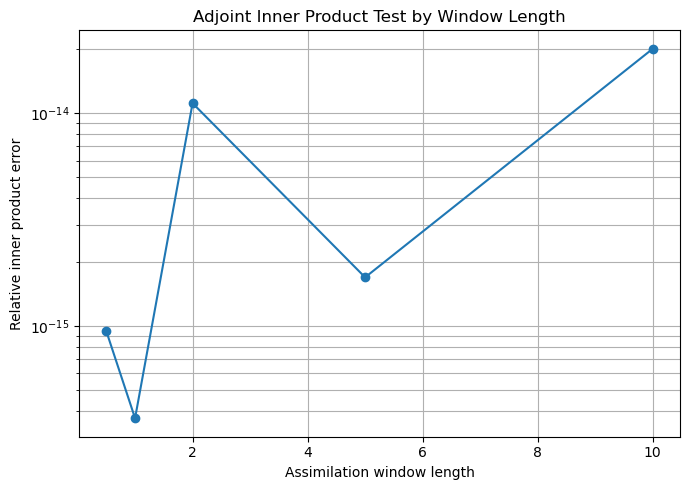

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/04_adjoint_inner_product_error_by_window.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(window_lengths, window_errors, marker="o")

ax.set_xlabel("Assimilation window length")
ax.set_ylabel("Relative inner product error")
ax.set_title("Adjoint Inner Product Test by Window Length")
ax.grid(True, which="both")

fig.tight_layout()

fig_path = FIGURE_DIR / "04_adjoint_inner_product_error_by_window.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 14. 결과 저장

이번 실습에서 생성한 기준 trajectory와 adjoint result를 저장한다.

In [14]:
np.save(TRAJECTORY_DIR / "04_adjoint_reference_trajectory.npy", trajectory_ref)
np.save(TRAJECTORY_DIR / "04_adjoint_time.npy", time)
np.save(TRAJECTORY_DIR / "04_adjoint_terminal_x.npy", adjoint_results["terminal_x"])
np.save(TRAJECTORY_DIR / "04_adjoint_terminal_y.npy", adjoint_results["terminal_y"])
np.save(TRAJECTORY_DIR / "04_adjoint_terminal_z.npy", adjoint_results["terminal_z"])

print("Saved adjoint results to:", TRAJECTORY_DIR)

Saved adjoint results to: /Users/sanggyu/projects/lorenz-da-lab/outputs/trajectories


## 15. 이번 실습 정리

이번 노트북에서는 Lorenz-63 Euler TLM에 대응하는 adjoint model을 구현하고 검증했다.

확인한 내용은 다음과 같다.

1. Euler TLM matrix는 다음과 같다.

$$
M_n = I + \Delta t J(\mathbf{x}_n)
$$

2. 이에 대응하는 adjoint step은 다음과 같다.

$$
\lambda_n = M_n^T \lambda_{n+1}
$$

3. One-step inner product test가 성립함을 확인했다.

$$
\langle M\delta \mathbf{x}, \lambda \rangle
=
\langle \delta \mathbf{x}, M^T \lambda \rangle
$$

4. Multi-step inner product test가 성립함을 확인했다.

$$
\langle \delta \mathbf{x}_N, \lambda_N \rangle
=
\langle \delta \mathbf{x}_0, \lambda_0 \rangle
$$

5. Adjoint variable은 terminal time에서 시작해 backward 방향으로 전파된다.

다음 실습에서는 이 adjoint model을 이용해 4D-Var cost function의 gradient를 계산한다.

In [15]:
print("네 번째 실습 완료")
print("다음 실습: 05_lorenz63_4dvar_euler.ipynb")

네 번째 실습 완료
다음 실습: 05_lorenz63_4dvar_euler.ipynb
